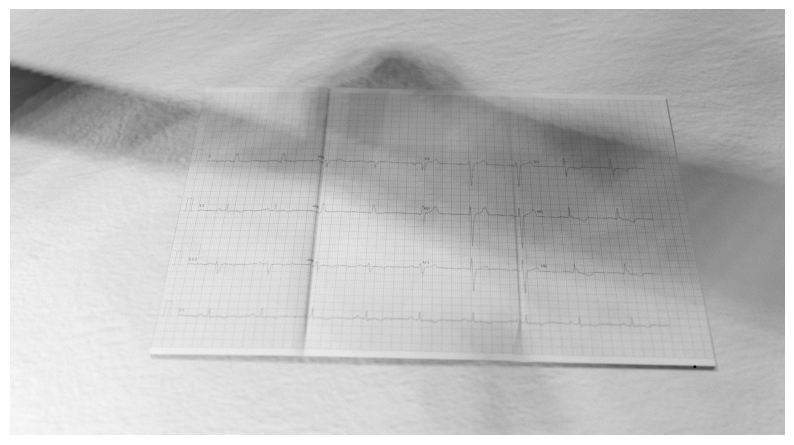

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
ind = 10
orig_image = "/Users/griffin/Documents/Data_Science_Projects/bhf_classification/data/train/train_" + str(ind).zfill(6) + ".png"
image = cv2.imread(orig_image)

# You can now proceed with your original image processing pipeline:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
h_img, w_img = image.shape[:2]  # Image size

# **1️⃣ Increase Contrast using CLAHE**
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
high_contrast = clahe.apply(gray)

# **2️⃣ Apply Edge Detection (Canny)**
edges = cv2.Canny(high_contrast, 10, 150)

# Apply Histogram Equalization to improve contrast
equalized_image = cv2.equalizeHist(gray)

# Apply Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       cv2.THRESH_BINARY, 11, 2)

# Apply Morphological Transformation to remove small noise
kernel = np.ones((5, 5), np.uint8)
cleaned_image = cv2.morphologyEx(adaptive_thresh, cv2.MORPH_CLOSE, kernel)

# Apply Canny Edge Detection after cleaning up the image
edges2 = cv2.Canny(cleaned_image, 50, 150)

# **3️⃣ Find Contours to Detect the Document**
# contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours, _ = cv2.findContours(edges2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
document_contour = max(contours, key=cv2.contourArea)  # Find largest contour

# Draw the largest contour on the original image (make a copy to avoid modifying the original image)
image_with_contour = gray.copy()

# Draw the contour in green color with a thickness of 3
cv2.drawContours(image_with_contour, [document_contour], -1, (0, 255, 0), 3)


# Plot the image using Matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(image_with_contour, cmap = 'gray')
plt.axis('off')  # Hide axes
plt.show()


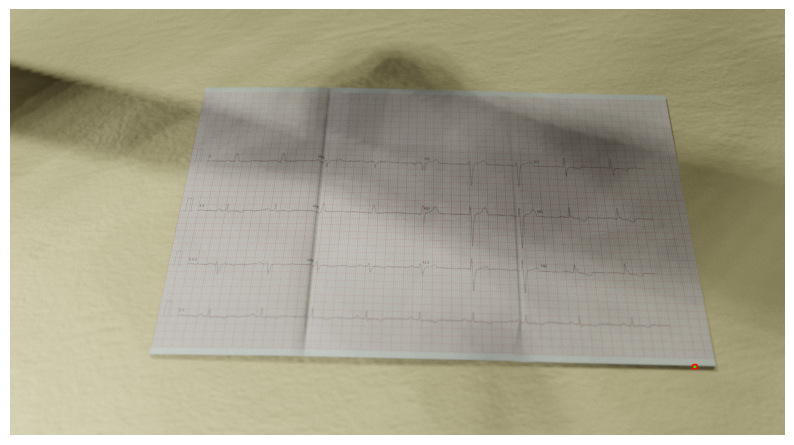

In [2]:

# **4️⃣ Get the Document's Corners (Bounding Box)**
rect = cv2.minAreaRect(document_contour)
box = cv2.boxPoints(rect)
box = np.intp(box)  # Convert to integer points

# **5️⃣ Order the Corners: Top-left, Top-right, Bottom-right, Bottom-left**
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left
    return rect

# Order the points
ordered_corners = order_points(box)

# **6️⃣ Lower the Bottom Corners by a Fraction**
# Get the fraction to adjust the bottom corners (you can change this value)
fraction_to_lower = 1.0  # Lower the bottom corners by 10%

# Lower the y-coordinates of the bottom-left and bottom-right corners
ordered_corners[2][1] += int(fraction_to_lower * (ordered_corners[2][1] - ordered_corners[3][1]))
ordered_corners[3][1] += int(fraction_to_lower * (ordered_corners[2][1] - ordered_corners[3][1]))


# **6️⃣ Plot the Ordered Corners on the Image**
# Convert ordered corners to integer type for OpenCV
ordered_corners_int = np.int32(ordered_corners)

# Draw circles at each of the four corners
for point in ordered_corners_int:
    cv2.circle(image, tuple(point), 10, (0, 0, 255), -1)  # Red circle (filled)

# Draw lines connecting the corners to form a bounding box
cv2.polylines(image, [ordered_corners_int], isClosed=True, color=(0, 255, 0), thickness=3)  # Green bounding box

# Convert the image from BGR (OpenCV default) to RGB (Matplotlib expects RGB)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# **7️⃣ Plot with Matplotlib**
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.axis('off')  # Remove axis
plt.show()


In [3]:
# **8️⃣ Calculate the Target Size Dynamically Based on Transformed Corners**
width = int(np.linalg.norm(ordered_corners[0] - ordered_corners[1]))  # Horizontal distance
height = int(np.linalg.norm(ordered_corners[0] - ordered_corners[3]))  # Vertical distance

# **9️⃣ Compute the Perspective Transform**
target_points = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype="float32")
M = cv2.getPerspectiveTransform(ordered_corners, target_points)

# Apply the perspective warp (assuming transformed_image is defined)
warped_image = cv2.warpPerspective(image, M, (width, height))

# **🔟 Adjust the Final Size Based on the Transformed Corners**
transformed_corners = cv2.perspectiveTransform(np.array([ordered_corners], dtype="float32"), M)[0]
min_x = min(transformed_corners[:, 0])
max_x = max(transformed_corners[:, 0])
min_y = min(transformed_corners[:, 1])
max_y = max(transformed_corners[:, 1])

new_width = int(max_x - min_x)
new_height = int(max_y - min_y)

# **1️⃣1️⃣ Adjust the Warp Again if Necessary**
padding_factor_width = 1.0
padding_factor_height = 2.0
new_width = int(new_width * (1 + padding_factor_width))
new_height = int(new_height * (1 + padding_factor_height))

# **1️⃣2️⃣ Final Perspective Warp with Correct Dimensions**
target_points = np.array([[0, 0], [new_width - 1, 0], [new_width - 1, new_height - 1], [0, new_height - 1]], dtype="float32")
M_final = cv2.getPerspectiveTransform(ordered_corners, target_points)

final_warped_image = cv2.warpPerspective(image, M_final, (new_width, new_height))

# **1️⃣3️⃣ Save or Display the Corrected Image**
cv2.imwrite("cropped_" + str(ind).zfill(6) + ".jpg", final_warped_image)


True

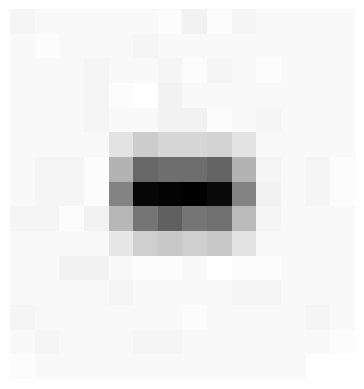

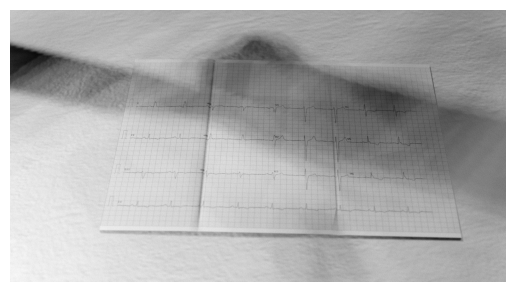

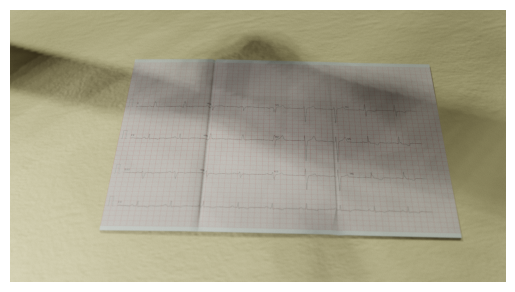

In [4]:

# Read the image in RGB format (OpenCV loads in BGR by default)
cropped_document = cv2.imread("cropped_" + str(ind).zfill(6) + ".jpg")
cropped_document = cv2.cvtColor(cropped_document, cv2.COLOR_BGR2GRAY)

image = cv2.imread(orig_image)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(cropped_document, cmap = 'gray')
plt.axis("off")  # Hide axis
plt.show()

plt.imshow(gray, cmap='grey')
plt.axis("off")  # Hide axis
plt.show()

plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()
